In [13]:
import torch
from torch.utils.data import Dataset


class FMRIDataset(Dataset):
    """
    Dataset for 3D fMRI volumes.
    Input shape:
        (N, 64, 64, 34)

    Returned shape:
        (1, 64, 64, 34)
    """

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        volume = self.X[idx]

        # Add channel dimension
        volume = volume.unsqueeze(0)

        label = self.y[idx]

        return volume, label


if __name__ == "__main__":

    import numpy as np

    X = np.load("prepared_data/X_train.npy")
    y = np.load("prepared_data/y_train.npy")

    dataset = FMRIDataset(X, y)

    print("Dataset size:", len(dataset))

    volume, label = dataset[0]

    print("Volume shape:", volume.shape)
    print("Label:", label)

Dataset size: 147
Volume shape: torch.Size([1, 64, 64, 34])
Label: tensor(0)


In [14]:
import torch
import torch.nn as nn


class FMRI3DCNN(nn.Module):

    def __init__(self):

        super(FMRI3DCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv3d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(16),

            nn.ReLU(inplace=True),

            nn.MaxPool3d(2),

            nn.Conv3d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(32),

            nn.ReLU(inplace=True),

            nn.MaxPool3d(2),

            nn.Conv3d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(64),

            nn.ReLU(inplace=True),

            nn.MaxPool3d(2),

            nn.AdaptiveAvgPool3d(1)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64, 64),

            nn.ReLU(inplace=True),

            nn.Dropout(0.5),

            nn.Linear(64, 2)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


if __name__ == "__main__":

    model = FMRI3DCNN()

    dummy = torch.randn(
        2,
        1,
        64,
        64,
        34
    )

    output = model(dummy)

    print("Output shape:", output.shape)

Output shape: torch.Size([2, 2])


Epoch 1 TrainLoss=0.7064 ValLoss=0.6909 ValAcc=0.5667
Epoch 2 TrainLoss=0.6903 ValLoss=0.6819 ValAcc=0.6000
Epoch 3 TrainLoss=0.6920 ValLoss=0.6796 ValAcc=0.5667
Epoch 4 TrainLoss=0.6509 ValLoss=0.6728 ValAcc=0.5667
Epoch 5 TrainLoss=0.6867 ValLoss=0.6711 ValAcc=0.5667
Epoch 6 TrainLoss=0.6735 ValLoss=0.6727 ValAcc=0.5667
Epoch 7 TrainLoss=0.6669 ValLoss=0.6650 ValAcc=0.5667
Epoch 8 TrainLoss=0.6561 ValLoss=0.6639 ValAcc=0.6000
Epoch 9 TrainLoss=0.6618 ValLoss=0.6649 ValAcc=0.5333
Epoch 10 TrainLoss=0.6449 ValLoss=0.6613 ValAcc=0.6000
Epoch 11 TrainLoss=0.6598 ValLoss=0.6580 ValAcc=0.6333
Epoch 12 TrainLoss=0.6474 ValLoss=0.6580 ValAcc=0.5000
Epoch 13 TrainLoss=0.6295 ValLoss=0.6529 ValAcc=0.6000
Epoch 14 TrainLoss=0.6610 ValLoss=0.6693 ValAcc=0.5667
Epoch 15 TrainLoss=0.6238 ValLoss=0.6800 ValAcc=0.5667
Epoch 16 TrainLoss=0.6336 ValLoss=0.6475 ValAcc=0.5667
Epoch 17 TrainLoss=0.6245 ValLoss=0.6450 ValAcc=0.6000
Epoch 18 TrainLoss=0.5887 ValLoss=0.6451 ValAcc=0.6000
Epoch 19 TrainLoss=

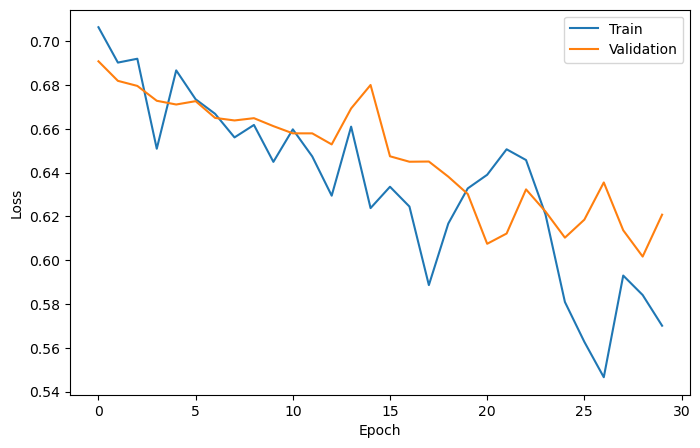

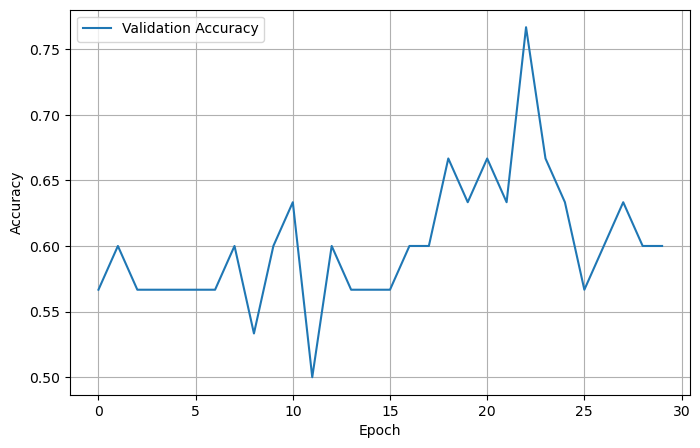

In [23]:
import os
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

os.makedirs("results", exist_ok=True)

X = np.load("prepared_data/X_train.npy")
y = np.load("prepared_data/y_train.npy")

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_dataset = FMRIDataset(X_train,y_train)
val_dataset = FMRIDataset(X_val,y_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = FMRI3DCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

best_acc = 0

train_losses = []
val_losses = []
val_accs = []

for epoch in range(30):

    model.train()

    running_loss = 0

    for X_batch,y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs,y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss/len(train_loader)

    train_losses.append(train_loss)

    model.eval()

    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():

        for X_batch,y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs,y_batch)

            val_loss += loss.item()

            preds = outputs.argmax(1)

            correct += (preds==y_batch).sum().item()

            total += y_batch.size(0)

    val_loss /= len(val_loader)

    val_losses.append(val_loss)

    val_acc = correct/total
    
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1} "
        f"TrainLoss={train_loss:.4f} "
        f"ValLoss={val_loss:.4f} "
        f"ValAcc={val_acc:.4f}"
    )

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "results/model_3dcnn.pth"
        )

print("Best Accuracy:", best_acc)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.savefig(
    "results/loss_curve.png",
    dpi=300
)

plt.show()

# Accuracy Curve
plt.figure(figsize=(8,5))
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    "results/accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()